# Análisis Exploratorio de InpactorDB2
## TFM - Detección automática de TEs mediante Deep Learning

**Autor:** Jorge González Gilbaja  
**Fecha:** 09/10/2025  
**Tarea:** T1.1 - Análisis y selección de secuencias consenso

---

## Objetivo
Analizar el conjunto de datos InpactorDB2 para:
- Entender la estructura y características de los TEs consenso
- Identificar distribuciones de longitudes y contenido GC
- Clasificar por superfamilias y familias
- Definir criterios de selección para el dataset sintético

## 0. Instalar librerías

In [ ]:
# !pip install biopython pandas matplotlib seaborn scikit-learn

## 1. Importar librerías

In [5]:
import re
from collections import defaultdict, Counter
from Bio import SeqIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Configuración de rutas

In [6]:
# Ruta al archivo FASTA de InpactorDB2
FASTA_FILE = "../data/r.1.5_all.fasta"

# Prefijo para archivos de salida
OUTPUT_PREFIX = "analisis"

## 3. Función para parsear headers

In [7]:
def parse_header(header):
    """
    Parsear el header del FASTA para extraer información relevante.
    Formato esperado: >rnd-X_family-Y_Z#CLASSI/SUPERFAMILY/FAMILY Species
    """
    info = {
        'full_header': header,
        'rnd_id': None,
        'family_id': None,
        'copy_number': None,
        'classification': None,
        'order': None,
        'superfamily': None,
        'family': None,
        'species': None
    }
    
    # Extraer rnd-X
    rnd_match = re.search(r'rnd-(\d+)', header)
    if rnd_match:
        info['rnd_id'] = int(rnd_match.group(1))
    
    # Extraer family-Y
    family_match = re.search(r'family-(\d+)', header)
    if family_match:
        info['family_id'] = int(family_match.group(1))
    
    # Extraer copy number (_Z)
    copy_match = re.search(r'_(\d+)#', header)
    if copy_match:
        info['copy_number'] = int(copy_match.group(1))
    
    # Extraer clasificación (después de #)
    class_match = re.search(r'#([^\s]+)', header)
    if class_match:
        classification = class_match.group(1)
        info['classification'] = classification
        
        # Dividir por /
        parts = classification.split('/')
        if len(parts) >= 1:
            info['order'] = parts[0]  # CLASSI
        if len(parts) >= 2:
            info['superfamily'] = parts[1]  # LTR, LINE, SINE, etc.
        if len(parts) >= 3:
            info['family'] = parts[2]  # GYPSY, COPIA, etc.
    
    # Extraer especie (último elemento después de espacio)
    species_match = re.search(r'\s+(\S+)$', header)
    if species_match:
        info['species'] = species_match.group(1)
    
    return info

# Test con un ejemplo
test_header = "rnd-1_family-628_3#CLASSI/LTR/GYPSY Blastomussa"
parsed = parse_header(test_header)
print("✅ Función de parsing creada. Ejemplo:")
print(f"   Familia: {parsed['family']}")
print(f"   Superfamilia: {parsed['superfamily']}")
print(f"   Especie: {parsed['species']}")

✅ Función de parsing creada. Ejemplo:
   Familia: GYPSY
   Superfamilia: LTR
   Especie: Blastomussa


## 4. Función para analizar el FASTA

In [8]:
def analyze_fasta(fasta_file):
    """
    Analizar un archivo FASTA
    """
    sequences = []
    lengths = []
    gc_contents = []
    parsed_info = []
    
    print(f"📖 Analizando {fasta_file}...")
    
    for record in SeqIO.parse(fasta_file, "fasta"):
        seq = str(record.seq)
        length = len(seq)
        
        # Calcular contenido GC
        gc = (seq.upper().count('G') + seq.upper().count('C')) / length * 100
        
        # Parsear header
        info = parse_header(record.description)
        info['length'] = length
        info['gc_content'] = gc
        info['seq_id'] = record.id
        
        sequences.append(seq)
        lengths.append(length)
        gc_contents.append(gc)
        parsed_info.append(info)
    
    df = pd.DataFrame(parsed_info)
    print(f"✅ Análisis completo: {len(df)} secuencias procesadas")
    
    return df, sequences

print("✅ Función de análisis creada")

✅ Función de análisis creada


## 5. EJECUTAR ANÁLISIS

In [10]:
import time

start_time = time.time()

df, sequences = analyze_fasta(FASTA_FILE)

elapsed_time = time.time() - start_time
print(f"\n⏱️ Tiempo de análisis: {elapsed_time:.2f} segundos")
print(f"\n📊 Vista previa del DataFrame:")
display(df.head())

📖 Analizando ../data/r.1.5_all.fasta...
✅ Análisis completo: 162293 secuencias procesadas

⏱️ Tiempo de análisis: 3.05 segundos

📊 Vista previa del DataFrame:


,full_header,rnd_id,family_id,copy_number,classification,order,superfamily,family,species,length,gc_content,seq_id
0,rnd-1_family-628_3#CLASSI/LTR/GYPSY Blastomussa,1.0,628.0,3.0,CLASSI/LTR/GYPSY,CLASSI,LTR,GYPSY,Blastomussa,4751,44.369606,rnd-1_family-628_3#CLASSI/LTR/GYPSY
1,rnd-6_family-10801#CLASSI/LTR/GYPSY Blastomussa,6.0,10801.0,NaN,CLASSI/LTR/GYPSY,CLASSI,LTR,GYPSY,Blastomussa,5241,49.017363,rnd-6_family-10801#CLASSI/LTR/GYPSY
2,rnd-5_family-9050#CLASSI/LTR/GYPSY Blastomussa,5.0,9050.0,NaN,CLASSI/LTR/GYPSY,CLASSI,LTR,GYPSY,Blastomussa,4461,45.998655,rnd-5_family-9050#CLASSI/LTR/GYPSY
3,rnd-6_family-8316#CLASSI/LTR/GYPSY Blastomussa,6.0,8316.0,NaN,CLASSI/LTR/GYPSY,CLASSI,LTR,GYPSY,Blastomussa,6192,43.846899,rnd-6_family-8316#CLASSI/LTR/GYPSY
4,rnd-6_family-10587#CLASSI/LTR/GYPSY Blastomussa,6.0,10587.0,NaN,CLASSI/LTR/GYPSY,CLASSI,LTR,GYPSY,Blastomussa,4751,44.369606,rnd-6_family-10587#CLASSI/LTR/GYPSY


## 6. Generar estadísticas descriptivas

In [11]:
def generate_statistics(df):
    """
    Generar estadísticas descriptivas
    """
    stats = {}
    
    stats['total_sequences'] = len(df)
    stats['unique_families'] = df['family_id'].nunique()
    stats['unique_species'] = df['species'].nunique()
    
    # Estadísticas de longitud
    stats['length_mean'] = df['length'].mean()
    stats['length_median'] = df['length'].median()
    stats['length_min'] = df['length'].min()
    stats['length_max'] = df['length'].max()
    stats['length_std'] = df['length'].std()
    
    # Estadísticas de GC
    stats['gc_mean'] = df['gc_content'].mean()
    stats['gc_median'] = df['gc_content'].median()
    stats['gc_std'] = df['gc_content'].std()
    
    # Distribución por clasificación
    stats['order_distribution'] = df['order'].value_counts().to_dict()
    stats['superfamily_distribution'] = df['superfamily'].value_counts().to_dict()
    stats['family_distribution'] = df['family'].value_counts().to_dict()
    
    return stats

# Generar estadísticas
stats = generate_statistics(df)

print("✅ Estadísticas generadas")

✅ Estadísticas generadas


## 7. Reporte de estadísticas

In [12]:
print("="*70)
print("REPORTE DE ANÁLISIS - InpactorDB2")
print("="*70)

print(f"\n📊 ESTADÍSTICAS GENERALES")
print(f"  Total de secuencias: {stats['total_sequences']:,}")
print(f"  Familias únicas: {stats['unique_families']:,}")
print(f"  Especies únicas: {stats['unique_species']:,}")

print(f"\n📏 LONGITUDES")
print(f"  Media: {stats['length_mean']:.2f} bp")
print(f"  Mediana: {stats['length_median']:.2f} bp")
print(f"  Rango: {stats['length_min']:,} - {stats['length_max']:,} bp")
print(f"  Desviación estándar: {stats['length_std']:.2f} bp")

print(f"\n🧬 CONTENIDO GC")
print(f"  Media: {stats['gc_mean']:.2f}%")
print(f"  Mediana: {stats['gc_median']:.2f}%")
print(f"  Desviación estándar: {stats['gc_std']:.2f}%")

print(f"\n🏷️  DISTRIBUCIÓN POR ORDEN (CLASSI)")
for order, count in sorted(stats['order_distribution'].items(), 
                           key=lambda x: x[1], reverse=True):
    percentage = (count / stats['total_sequences']) * 100
    print(f"  {order}: {count:,} ({percentage:.1f}%)")

print(f"\n🏷️  DISTRIBUCIÓN POR SUPERFAMILIA (Top 10)")
for superfam, count in sorted(stats['superfamily_distribution'].items(), 
                              key=lambda x: x[1], reverse=True)[:10]:
    percentage = (count / stats['total_sequences']) * 100
    print(f"  {superfam}: {count:,} ({percentage:.1f}%)")

print(f"\n🏷️  DISTRIBUCIÓN POR FAMILIA (Top 20)")
for fam, count in sorted(stats['family_distribution'].items(), 
                        key=lambda x: x[1], reverse=True)[:20]:
    percentage = (count / stats['total_sequences']) * 100
    print(f"  {fam}: {count:,} ({percentage:.1f}%)")

print(f"\n🌍 TOP 10 ESPECIES")
species_counts = df['species'].value_counts().head(10)
for species, count in species_counts.items():
    percentage = (count / stats['total_sequences']) * 100
    print(f"  {species}: {count:,} ({percentage:.1f}%)")

print("\n" + "="*70)

REPORTE DE ANÁLISIS - InpactorDB2

📊 ESTADÍSTICAS GENERALES
  Total de secuencias: 162,293
  Familias únicas: 8,128
  Especies únicas: 1,587

📏 LONGITUDES
  Media: 3438.77 bp
  Mediana: 3212.00 bp
  Rango: 69 - 19,982 bp
  Desviación estándar: 2635.31 bp

🧬 CONTENIDO GC
  Media: 43.77%
  Mediana: 43.11%
  Desviación estándar: 7.92%

🏷️  DISTRIBUCIÓN POR ORDEN (CLASSI)
  CLASSI: 120,232 (74.1%)
  CLASSII: 42,061 (25.9%)

🏷️  DISTRIBUCIÓN POR SUPERFAMILIA (Top 10)
  LTR: 59,568 (36.7%)
  LINE: 52,070 (32.1%)
  TIR: 38,768 (23.9%)
  SINE: 4,014 (2.5%)
  DIRS: 3,255 (2.0%)
  HELITRON: 3,154 (1.9%)
  PLE: 1,325 (0.8%)
  CRYPTON: 139 (0.1%)

🏷️  DISTRIBUCIÓN POR FAMILIA (Top 20)
  GYPSY: 25,117 (15.5%)
  CR1: 25,095 (15.5%)
  ERV: 13,871 (8.5%)
  COPIA: 12,873 (7.9%)
  TC1MARINER: 12,376 (7.6%)
  HAT: 12,183 (7.5%)
  L1: 10,603 (6.5%)
  RTE: 6,091 (3.8%)
  TIR: 4,473 (2.8%)
  BELPAO: 4,409 (2.7%)
  I: 4,318 (2.7%)
  LINE: 3,267 (2.0%)
  DIRS: 3,255 (2.0%)
  HELITRON: 3,154 (1.9%)
  PIFHARBIN

## 8. Visualizaciones


📊 Visualizaciones guardadas en: analisis_visualizaciones.png


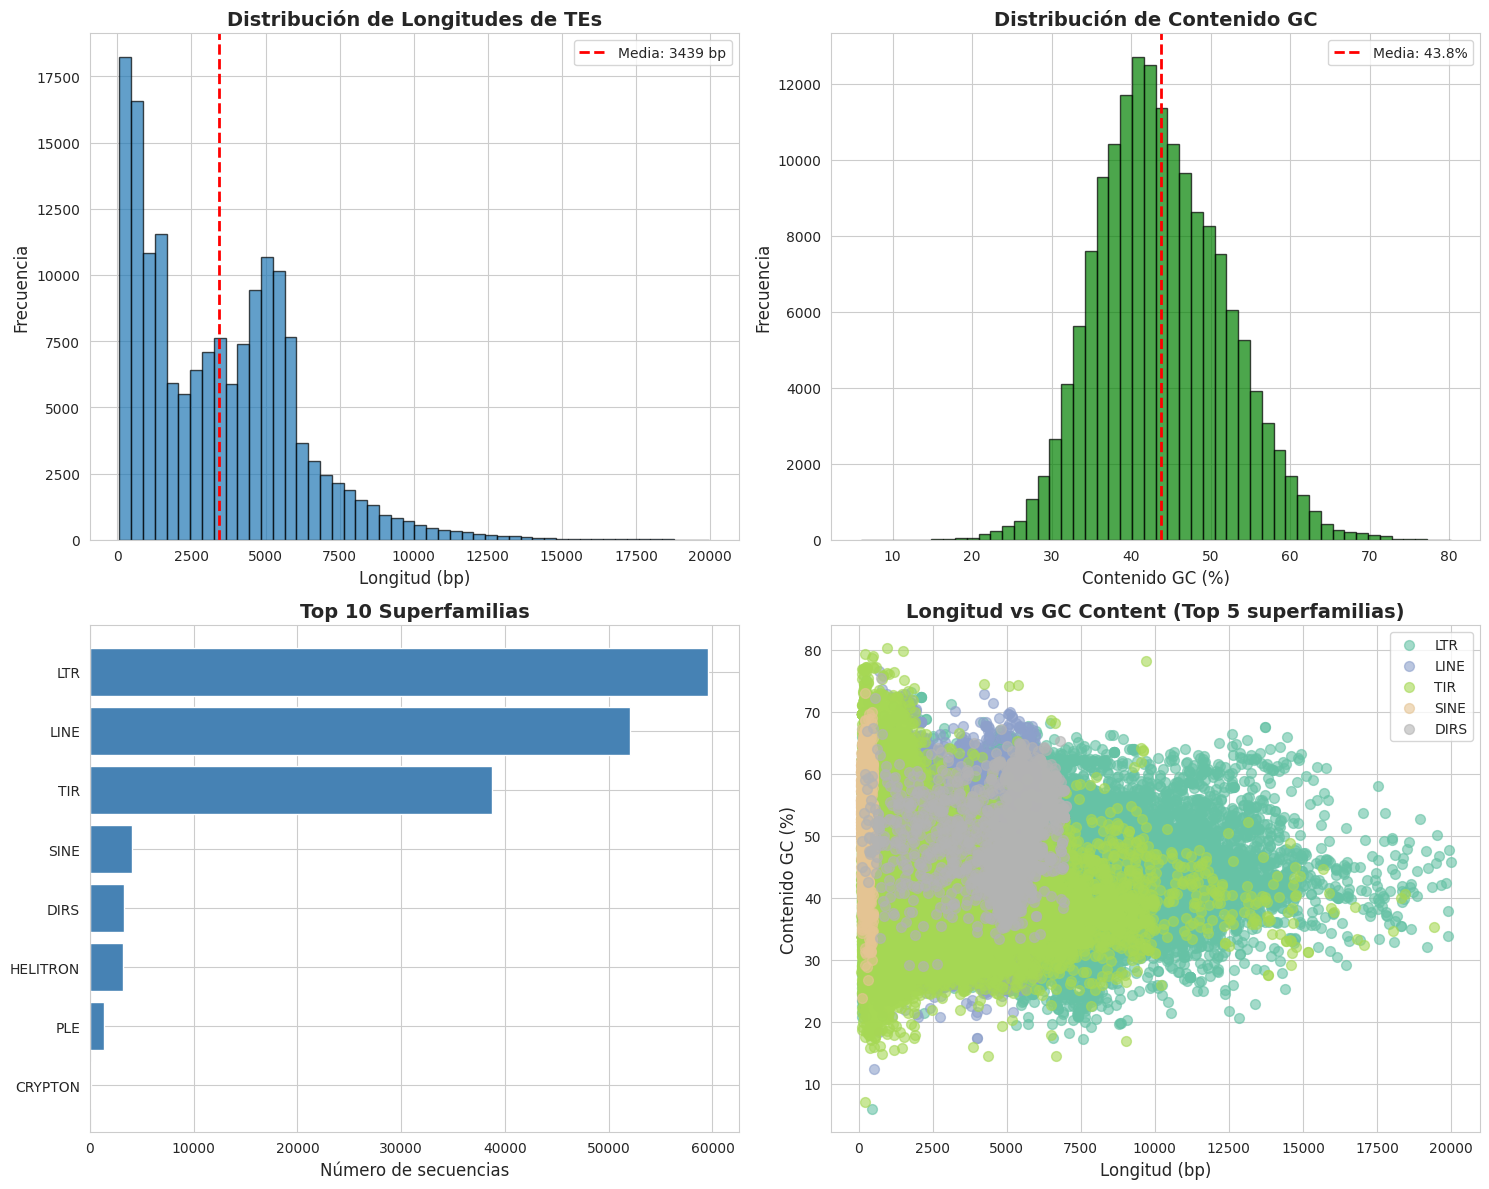

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histograma de longitudes
axes[0, 0].hist(df['length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Longitud (bp)', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].set_title('Distribución de Longitudes de TEs', fontsize=14, fontweight='bold')
axes[0, 0].axvline(df['length'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Media: {df["length"].mean():.0f} bp')
axes[0, 0].legend(fontsize=10)

# 2. Histograma de contenido GC
axes[0, 1].hist(df['gc_content'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Contenido GC (%)', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].set_title('Distribución de Contenido GC', fontsize=14, fontweight='bold')
axes[0, 1].axvline(df['gc_content'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Media: {df["gc_content"].mean():.1f}%')
axes[0, 1].legend(fontsize=10)

# 3. Distribución por superfamilia (Top 10)
superfam_counts = df['superfamily'].value_counts().head(10)
axes[1, 0].barh(range(len(superfam_counts)), superfam_counts.values, color='steelblue')
axes[1, 0].set_yticks(range(len(superfam_counts)))
axes[1, 0].set_yticklabels(superfam_counts.index, fontsize=10)
axes[1, 0].set_xlabel('Número de secuencias', fontsize=12)
axes[1, 0].set_title('Top 10 Superfamilias', fontsize=14, fontweight='bold')
axes[1, 0].invert_yaxis()

# 4. Scatter: Longitud vs GC content por superfamilia (Top 5)
top_superfams = df['superfamily'].value_counts().head(5).index
df_top = df[df['superfamily'].isin(top_superfams)]
colors = plt.cm.Set2(np.linspace(0, 1, len(top_superfams)))
for i, superfam in enumerate(top_superfams):
    subset = df_top[df_top['superfamily'] == superfam]
    axes[1, 1].scatter(subset['length'], subset['gc_content'], 
                      label=superfam, alpha=0.6, s=50, color=colors[i])
axes[1, 1].set_xlabel('Longitud (bp)', fontsize=12)
axes[1, 1].set_ylabel('Contenido GC (%)', fontsize=12)
axes[1, 1].set_title('Longitud vs GC Content (Top 5 superfamilias)', 
                     fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)

plt.tight_layout()

# Guardar figura
output_file = f'{OUTPUT_PREFIX}_visualizaciones.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n📊 Visualizaciones guardadas en: {output_file}")

plt.show()

## 9. Exportar datos a CSV

In [14]:
output_csv = f'{OUTPUT_PREFIX}.csv'
df.to_csv(output_csv, index=False)
print(f"💾 Datos exportados a: {output_csv}")
print(f"   Tamaño del archivo: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB en memoria")
print(f"   Filas: {len(df):,}")
print(f"   Columnas: {len(df.columns)}")

💾 Datos exportados a: analisis.csv
   Tamaño del archivo: 76.53 MB en memoria
   Filas: 162,293
   Columnas: 12


## 10. Análisis adicional: Distribuciones por familia

In [15]:
# Crear tabla resumen por familia
family_summary = df.groupby('family').agg({
    'length': ['count', 'mean', 'std', 'min', 'max'],
    'gc_content': ['mean', 'std']
}).round(2)

family_summary.columns = ['N_secuencias', 'Long_media', 'Long_std', 'Long_min', 'Long_max', 
                          'GC_medio', 'GC_std']
family_summary = family_summary.sort_values('N_secuencias', ascending=False)

print("\n📋 RESUMEN POR FAMILIA (Top 20):")
print("="*100)
display(family_summary.head(20))

# Guardar resumen
family_summary.to_csv(f'{OUTPUT_PREFIX}_family_summary.csv')
print(f"\n💾 Resumen por familia guardado en: {OUTPUT_PREFIX}_family_summary.csv")


📋 RESUMEN POR FAMILIA (Top 20):


,N_secuencias,Long_media,Long_std,Long_min,Long_max,GC_medio,GC_std
family,,,,,,,
GYPSY,25117,6044.49,2804.36,103,19982,45.88,7.42
CR1,25095,3073.23,1318.57,500,5999,43.70,7.46
ERV,13871,1978.12,2644.58,100,18951,48.71,6.19
COPIA,12873,5100.74,1817.05,101,19185,41.63,6.02
TC1MARINER,12376,1319.46,816.06,100,9835,41.06,5.27
HAT,12183,1571.97,1448.71,100,9903,41.54,8.63
L1,10603,3521.01,1802.92,500,6000,41.16,7.11
RTE,6091,2946.95,1252.16,500,5994,43.81,7.13
TIR,4473,932.32,1377.48,100,9967,40.33,9.15



💾 Resumen por familia guardado en: analisis_family_summary.csv
